# Unsupervised Learning: Geological Phenotypes for Quebec Mineral Prospectivity

**Owner:** Shinwoo Noh
**Input:** `processed(500)_geology_ml_training_data.csv`
**Environment:** Local (no Drive mount, no Colab-specific code)

### Preprocessing
- `CODE_LITH` is **already multi-hot encoded** in this file (224 binary columns, one per rock code — a row can have more than one code active, e.g. `S2A-S4D` → both `S2A`=1 and `S4D`=1). We do **not** re-encode it.
- `STRAT` is **not** encoded yet, and it is **not** a clean categorical column — it's a hyphen-delimited compound field just like `CODE_LITH` was before encoding (e.g. `'lo-lo-cl1-ag4'`). We replicate the same multi-hot approach used for `CODE_LITH`: split on `-`, dedupe, collapse rare tokens, then build one binary column per surviving token.
- `spatial_cluster` is a row index (0..N-1, all unique) carried over from preprocessing — not a real feature. We drop it.
- Three lithology columns have a data-entry bug (leading whitespace: `' I2C'`, `' M22'`, `' S6D'` exist as separate columns from the clean `I2C`, `M22`, `S6D`). We merge them before clustering.

### Pipeline overview
1. Load + fix known data issues
2. Feature engineering (log-transform minerals, multi-hot encode STRAT, drop leaky/redundant columns)
3. PCA → UMAP for dimensionality reduction and visualisation
4. K-means (primary) + GMM (secondary) clustering
5. Internal validation: silhouette, Davies-Bouldin, elbow, bootstrap stability
6. Geological interpretation: phenotype heatmap, UMAP scatter, Quebec map
7. Nested model test: XGBoost with raw features vs. phenotype vs. both

## 0. Setup

Run once in a terminal if these aren't already installed:
```bash
pip install umap-learn xgboost scikit-learn matplotlib seaborn pandas numpy
```

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, roc_auc_score, average_precision_score
)
import xgboost as xgb
import umap

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

# ── Local paths — adjust to wherever you keep the data on your machine ───────
DATA_PATH   = './processed(500)_geology_ml_training_data.csv'
OUTPUT_DIR  = './outputs_v4'
os.makedirs(OUTPUT_DIR, exist_ok=True)

MINERAL_COLS  = ['AU', 'AG', 'CU', 'CO', 'NI']
TARGET_COLS   = [f'target_{m}' for m in MINERAL_COLS]
MISSING_COLS  = [f'{m}_missing' for m in MINERAL_COLS]
DISTANCE_COLS = ['dist_fault', 'dist_cont']
NORM_COLS     = ['dist_fault_norm', 'dist_cont_norm']

print('Libraries loaded.')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded.


## 1. Load data + fix known issues

In [2]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f'Loaded: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

Loaded: 48,254 rows x 250 columns


In [3]:
# Filter out OUTSIDE_MAP rows to avoid degenerate, outlier-driven micro-clusters
outside_map_cols = [c for c in df_raw.columns if 'OUTSIDE_MAP' in c]
if outside_map_cols:
    for col in outside_map_cols:
        df_raw = df_raw[df_raw[col] != 1]
    print(f"Shape after filtering OUTSIDE_MAP rows: {df_raw.shape}")
else:
    # Fallback in case it's stored as an unencoded column attribute
    if 'OUTSIDE_MAP' in df_raw.columns:
        df_raw = df_raw[df_raw['OUTSIDE_MAP'] != 'OUTSIDE_MAP']
        print(f"Shape after filtering OUTSIDE_MAP rows: {df_raw.shape}")

Shape after filtering OUTSIDE_MAP rows: (48166, 250)


In [4]:
# ── 1a. Strip whitespace from column names and merge duplicate lithology cols ──
# The raw file has both 'I2C' and ' I2C' (leading space) as separate columns —
# same issue for 'M22'/' M22' and 'S6D'/' S6D'. These represent the same rock
# code and must be merged (logical OR) before clustering, or that lithology
# signal gets silently split across two columns.

df = df_raw.copy()
df.columns = [c.strip() if c.strip() not in df.columns or c == c.strip() else c for c in df.columns]

# Explicit merge for the three known dupes (safe even if already merged by the line above)
dupe_pairs = [(' I2C', 'I2C'), (' M22', 'M22'), (' S6D', 'S6D')]
for dirty, clean in dupe_pairs:
    if dirty in df_raw.columns and clean in df_raw.columns:
        df[clean] = (df_raw[dirty] == 1) | (df_raw[clean] == 1)
        df[clean] = df[clean].astype(int)
        if dirty in df.columns:
            df = df.drop(columns=[dirty])

print('Duplicate lithology columns merged.')
print('Remaining columns with whitespace:', [c for c in df.columns if c != c.strip()])
df.shape

Duplicate lithology columns merged.
Remaining columns with whitespace: []


(48166, 247)

In [5]:
# ── 1b. Identify the already-encoded CODE_LITH multi-hot columns ─────────────
# These are everything that isn't one of our known named columns. We DO NOT
# touch these — preprocessing already turned CODE_LITH into this set.

KNOWN_COLS = (
    ['spatial_cluster', 'CODE_LITH', 'STRAT', 'Sample_ID', 'Easting', 'Northing']
    + MINERAL_COLS + DISTANCE_COLS + NORM_COLS + TARGET_COLS + MISSING_COLS
    + ['hasImage']
)
lith_ohe_cols = [c for c in df.columns if c not in KNOWN_COLS]
print(f'Pre-encoded CODE_LITH columns found: {len(lith_ohe_cols)}')
print(lith_ohe_cols[:15], '...')

Pre-encoded CODE_LITH columns found: 221
['12G', '1B', 'BO', 'CB', 'CB+', 'CC', 'CL', 'CL+', 'CX', 'DM', 'F1', 'F2', 'Fe+', 'GL', 'GP'] ...


## 2. Feature engineering for clustering

Steps:
1. Drop `spatial_cluster` (row index, not a feature), `Sample_ID`, binary targets, normalised distance duplicates, and missing-flags (these describe assay coverage, not geology — keep them out of the *clustering* space, though they could be re-added later as a robustness check).
2. Log-transform the five mineral concentrations.
3. **Multi-hot encode `STRAT`** the same way `CODE_LITH` already was: split each value on `-`, dedupe per row, collapse rare tokens (< 20 occurrences) to `OTHER`, then one binary column per surviving token.
4. Z-score all continuous features. Leave the multi-hot lithology/strat columns as 0/1 (already on a natural common scale).

In [6]:
# ── 2a. Drop leaky / non-feature columns ─────────────────────────────────────
DROP_COLS = ['spatial_cluster', 'Sample_ID'] + TARGET_COLS + NORM_COLS + MISSING_COLS
drop_present = [c for c in DROP_COLS if c in df.columns]
df_feat = df.drop(columns=drop_present).copy()
print(f'Dropped: {drop_present}')
print(f'Remaining shape: {df_feat.shape}')

Dropped: ['spatial_cluster', 'Sample_ID', 'target_AU', 'target_AG', 'target_CU', 'target_CO', 'target_NI', 'dist_fault_norm', 'dist_cont_norm', 'AU_missing', 'AG_missing', 'CU_missing', 'CO_missing', 'NI_missing']
Remaining shape: (48166, 233)


In [7]:
# ── 2b. Log-transform mineral concentrations ─────────────────────────────────
# No NaNs expected here (already imputed in preprocessing), but we guard anyway.
for col in MINERAL_COLS:
    if df_feat[col].isna().any():
        df_feat[col] = df_feat[col].fillna(df_feat[col].median())
    df_feat[f'log_{col}'] = np.log1p(df_feat[col])

# Drop the raw concentration — log version is what we cluster on
df_feat = df_feat.drop(columns=MINERAL_COLS)
print('Log-transformed:', [f'log_{m}' for m in MINERAL_COLS])

Log-transformed: ['log_AU', 'log_AG', 'log_CU', 'log_CO', 'log_NI']


In [8]:
# ── 2c. Multi-hot encode STRAT (mirrors how CODE_LITH was already encoded) ───
# STRAT is a hyphen-delimited compound field, e.g. 'lo-lo-cl1-ag4' means the
# sample touches strat units 'lo', 'cl1', and 'ag4'. We split, dedupe per row,
# collapse rare units, then build one binary column per surviving unit.

RARE_THRESHOLD = 20  # a strat token must appear in at least this many rows to get its own column

def tokenize_strat(value):
    """Split a STRAT string on '-', strip whitespace, drop empty tokens."""
    if pd.isna(value):
        return set()
    tokens = [t.strip() for t in str(value).split('-')]
    return set(t for t in tokens if t != '')

strat_token_sets = df_feat['STRAT'].apply(tokenize_strat)

# Count token frequency across all rows (presence, not repetition, per row)
from collections import Counter
token_counts = Counter()
for tokens in strat_token_sets:
    token_counts.update(tokens)

keep_tokens = {tok for tok, cnt in token_counts.items() if cnt >= RARE_THRESHOLD}
print(f'STRAT tokens found: {len(token_counts)}  ->  kept (>= {RARE_THRESHOLD} occurrences): {len(keep_tokens)}')

# Remap rare tokens to OTHER, keep the rest
def remap_tokens(tokens):
    if not tokens:
        return {'NO_STRAT'}
    remapped = {t if t in keep_tokens else 'OTHER' for t in tokens}
    return remapped

strat_token_sets_remapped = strat_token_sets.apply(remap_tokens)

# Build the multi-hot matrix
final_strat_vocab = sorted(keep_tokens | {'OTHER', 'NO_STRAT'})
strat_ohe = pd.DataFrame(
    0, index=df_feat.index,
    columns=[f'STRAT_{tok}' for tok in final_strat_vocab]
)
for idx, tokens in strat_token_sets_remapped.items():
    for tok in tokens:
        strat_ohe.loc[idx, f'STRAT_{tok}'] = 1

print(f'STRAT multi-hot matrix: {strat_ohe.shape}')
strat_ohe.sum().sort_values(ascending=False).head(10)

STRAT tokens found: 3788  ->  kept (>= 20 occurrences): 698
STRAT multi-hot matrix: (48166, 700)


STRAT_OTHER       14864
STRAT_NO_STRAT     2205
STRAT_ob1           613
STRAT_lgi2a         530
STRAT_be1           428
STRAT_lsj2          420
STRAT_lgi3a         301
STRAT_vp            294
STRAT_esk4          270
STRAT_grd2          261
dtype: int64

In [9]:
# ── 2d. Assemble the full feature matrix ─────────────────────────────────────
df_feat = df_feat.drop(columns=['CODE_LITH', 'STRAT'])  # raw string versions no longer needed
df_feat = pd.concat([df_feat, strat_ohe], axis=1)

# Separate coordinates (kept for mapping, not used in clustering distance)
coord_cols = ['Easting', 'Northing']
df_coords = df_feat[coord_cols].copy()
df_cluster_raw = df_feat.drop(columns=coord_cols)

# hasImage is a flag, not geology — drop from clustering space too
if 'hasImage' in df_cluster_raw.columns:
    df_cluster_raw = df_cluster_raw.drop(columns=['hasImage'])

print(f'Final clustering feature matrix (pre-scaling): {df_cluster_raw.shape}')

Final clustering feature matrix (pre-scaling): (48166, 928)


In [10]:
# ── 2e. Z-score continuous features only (lith/strat columns are already 0/1) ──
binary_cols = (
    lith_ohe_cols
    + [c for c in df_cluster_raw.columns if c.startswith('STRAT_')]
)
binary_cols = [c for c in binary_cols if c in df_cluster_raw.columns]
continuous_cols = [c for c in df_cluster_raw.columns if c not in binary_cols]

print(f'Continuous features ({len(continuous_cols)}): {continuous_cols}')
print(f'Binary (lith + strat) features: {len(binary_cols)}')

scaler = StandardScaler()
df_scaled_cont = pd.DataFrame(
    scaler.fit_transform(df_cluster_raw[continuous_cols]),
    columns=continuous_cols,
    index=df_cluster_raw.index
)

X = pd.concat([df_scaled_cont, df_cluster_raw[binary_cols]], axis=1).values
feature_names = continuous_cols + binary_cols

print(f'\nFinal feature matrix X: {X.shape}')
assert not np.isnan(X).any(), 'NaNs remain in X — check the steps above'

Continuous features (7): ['dist_fault', 'dist_cont', 'log_AU', 'log_AG', 'log_CU', 'log_CO', 'log_NI']
Binary (lith + strat) features: 921

Final feature matrix X: (48166, 928)


## 3. PCA

We reduce dimensionality before clustering. k-means in very high-dimensional space suffers from the curse of dimensionality — pairwise distances converge and clusters become essentially random. PCA to 95% variance keeps the geochemically meaningful signal while dropping noise dimensions.

Components needed for 95% variance: 190 (out of 928 original)


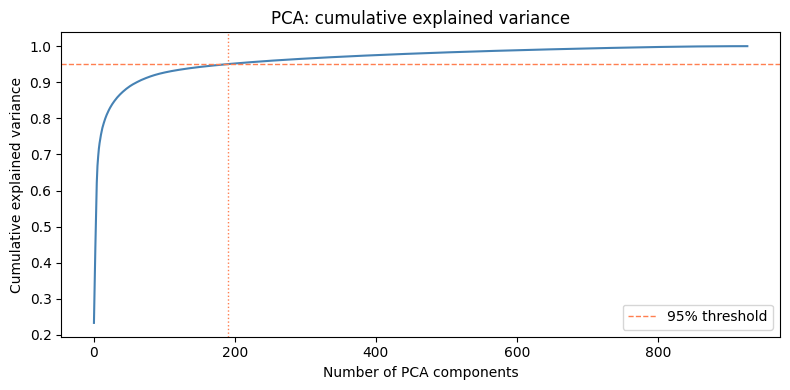

PCA output shape: (48166, 190)


In [11]:
pca_full = PCA(random_state=SEED)
pca_full.fit(X)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.searchsorted(cumvar, 0.95)) + 1
print(f'Components needed for 95% variance: {n_components_95} (out of {X.shape[1]} original)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cumvar, linewidth=1.5, color='steelblue')
ax.axhline(0.95, color='coral', linestyle='--', linewidth=1, label='95% threshold')
ax.axvline(n_components_95, color='coral', linestyle=':', linewidth=1)
ax.set_xlabel('Number of PCA components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA: cumulative explained variance')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pca_variance.png', dpi=150)
plt.show()

pca = PCA(n_components=n_components_95, random_state=SEED)
X_pca = pca.fit_transform(X)
print(f'PCA output shape: {X_pca.shape}')

## 4. UMAP

Run twice: **2D** for visualisation (scatter plots, Quebec map), **15D** as input to GMM. K-means always runs on `X_pca`, not UMAP output, because UMAP's non-linear distortion makes Euclidean distance hard to interpret.

In [12]:
print('Fitting UMAP 2D (for visualisation)...')
reducer_2d = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                        metric='euclidean', random_state=SEED)
X_umap2 = reducer_2d.fit_transform(X_pca)
print(f'UMAP 2D shape: {X_umap2.shape}')

print('Fitting UMAP 15D (for GMM input)...')
reducer_15d = umap.UMAP(n_components=15, n_neighbors=30, min_dist=0.0,
                         metric='euclidean', random_state=SEED)
X_umap15 = reducer_15d.fit_transform(X_pca)
print(f'UMAP 15D shape: {X_umap15.shape}')

Fitting UMAP 2D (for visualisation)...
UMAP 2D shape: (48166, 2)
Fitting UMAP 15D (for GMM input)...
UMAP 15D shape: (48166, 15)


## 5. K-means clustering (primary)

Sweep k from 4 to 10. Select k using elbow (kink in inertia) + silhouette (peak), then confirm with Davies-Bouldin (lower is better).

k=2  inertia=386019  silhouette=0.1800  DB=1.9611
k=3  inertia=356190  silhouette=0.1887  DB=1.8520
k=4  inertia=332957  silhouette=0.1883  DB=1.7599
k=5  inertia=310336  silhouette=0.1908  DB=1.5498
k=6  inertia=290887  silhouette=0.1885  DB=1.5009
k=7  inertia=276090  silhouette=0.1103  DB=1.8266
k=8  inertia=269249  silhouette=0.0960  DB=2.0050
k=9  inertia=263499  silhouette=0.0949  DB=2.0047
k=10  inertia=258314  silhouette=0.0932  DB=2.0225


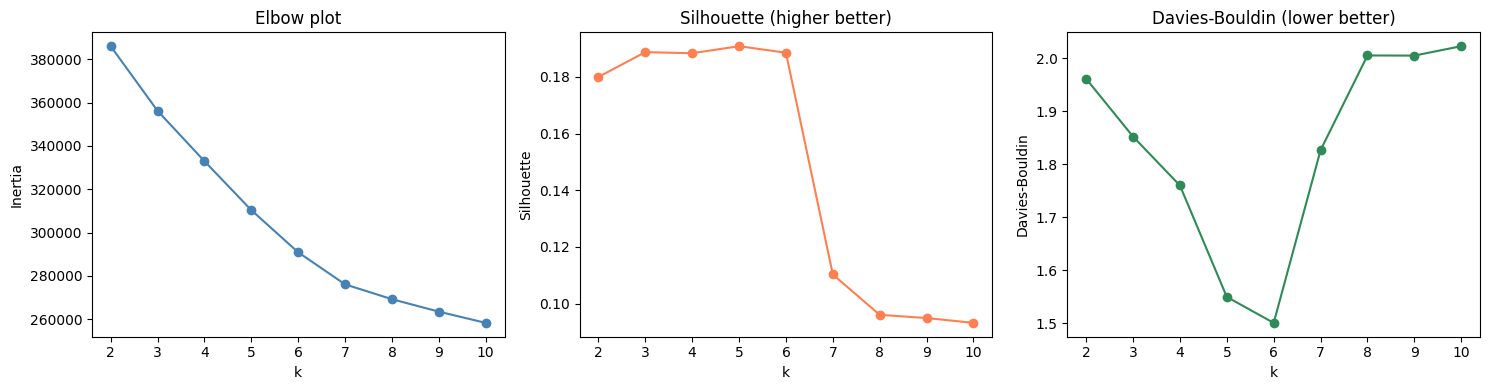

In [13]:
K_RANGE = range(2, 11)
inertias, silhouettes, db_scores = [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=SEED)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    n_sub = min(10_000, X_pca.shape[0])
    idx = np.random.choice(X_pca.shape[0], n_sub, replace=False)
    silhouettes.append(silhouette_score(X_pca[idx], labels[idx]))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    print(f'k={k}  inertia={km.inertia_:.0f}  silhouette={silhouettes[-1]:.4f}  DB={db_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow plot')
axes[1].plot(list(K_RANGE), silhouettes, 'o-', color='coral')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette (higher better)')
axes[2].plot(list(K_RANGE), db_scores, 'o-', color='seagreen')
axes[2].set_xlabel('k'); axes[2].set_ylabel('Davies-Bouldin'); axes[2].set_title('Davies-Bouldin (lower better)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/kmeans_selection.png', dpi=150)
plt.show()

In [14]:
# ── Set K_BEST based on the plots above ──────────────────────────────────────
K_BEST = 5  # <-- adjust after inspecting the elbow / silhouette / DB plots

km_final = KMeans(n_clusters=K_BEST, init='k-means++', n_init=50, random_state=SEED)
kmeans_labels = km_final.fit_predict(X_pca)

print(f'K-means with k={K_BEST} fitted.')
unique, counts = np.unique(kmeans_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:,} samples ({c/len(kmeans_labels)*100:.1f}%)')

K-means with k=5 fitted.
  Cluster 0: 14,513 samples (30.1%)
  Cluster 1: 1,950 samples (4.0%)
  Cluster 2: 27,215 samples (56.5%)
  Cluster 3: 2,956 samples (6.1%)
  Cluster 4: 1,532 samples (3.2%)


## 6. Bootstrap stability check

Re-run k-means 100 times on 80% subsamples, compute ARI against the full-data clustering. ARI > 0.8 = stable/real structure; < 0.6 = likely noise.

Bootstrap ARI: 0.9027 +/- 0.1046  (n=100 runs)
Clusters are STABLE.


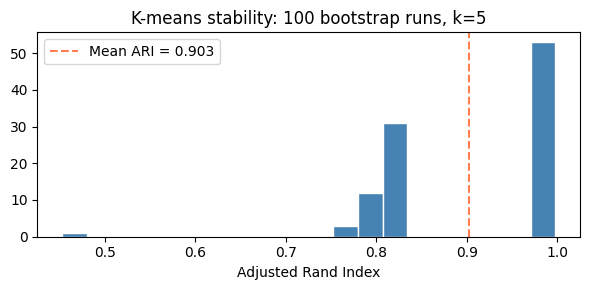

In [15]:
N_BOOTSTRAP = 100
SUBSAMPLE_FRAC = 0.80
ari_scores = []
n_total = X_pca.shape[0]
n_sub = int(n_total * SUBSAMPLE_FRAC)

for i in range(N_BOOTSTRAP):
    idx = np.random.choice(n_total, n_sub, replace=False)
    km_boot = KMeans(n_clusters=K_BEST, init='k-means++', n_init=10, random_state=i)
    boot_labels = km_boot.fit_predict(X_pca[idx])
    ari_scores.append(adjusted_rand_score(kmeans_labels[idx], boot_labels))

ari_mean, ari_std = np.mean(ari_scores), np.std(ari_scores)
print(f'Bootstrap ARI: {ari_mean:.4f} +/- {ari_std:.4f}  (n={N_BOOTSTRAP} runs)')
if ari_mean > 0.8:
    print('Clusters are STABLE.')
elif ari_mean > 0.6:
    print('Clusters are MODERATELY stable — consider a different k.')
else:
    print('Clusters are UNSTABLE — try lowering k or revisiting features.')

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(ari_scores, bins=20, color='steelblue', edgecolor='white')
ax.axvline(ari_mean, color='coral', linestyle='--', label=f'Mean ARI = {ari_mean:.3f}')
ax.set_xlabel('Adjusted Rand Index')
ax.set_title(f'K-means stability: 100 bootstrap runs, k={K_BEST}')
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/bootstrap_stability.png', dpi=150)
plt.show()

## 7. Gaussian Mixture Model (secondary)

GMM gives soft/probabilistic assignments. Select `n_components` via BIC, then compare to k-means via ARI.

In [16]:
# ── Fair comparison: GMM with n_components matched to K_BEST (instead of BIC-optimal) ──
# BIC kept decreasing all the way to n=10 with no turning point, so the
# "BIC-optimal" n=10 just hit the edge of our search range rather than finding
# a true minimum. Comparing k-means(k=3) to GMM(n=10) via ARI is not a fair
# test anyway — two solutions with very different cluster counts will rarely
# agree by chance. Here we match GMM to K_BEST so the ARI comparison actually
# tests whether the two algorithms agree on the SAME number of groups.

gmm_matched = GaussianMixture(
    n_components=K_BEST,
    covariance_type='full',
    n_init=20,
    random_state=SEED
)
gmm_matched.fit(X_umap15)
gmm_matched_labels = gmm_matched.predict(X_umap15)
gmm_matched_proba = gmm_matched.predict_proba(X_umap15)

ari_km_gmm_matched = adjusted_rand_score(kmeans_labels, gmm_matched_labels)
print(f'ARI between K-means (k={K_BEST}) and GMM (n={K_BEST}, matched): {ari_km_gmm_matched:.4f}')

if ari_km_gmm_matched > 0.7:
    print('Good agreement — structure is algorithm-independent.')
elif ari_km_gmm_matched > 0.4:
    print('Moderate agreement — some shared structure, but not fully consistent.')
else:
    print('Low agreement — the two algorithms still see different structure at the same k.')

# Cluster size distribution for the matched GMM, for comparison against k-means
unique, counts = np.unique(gmm_matched_labels, return_counts=True)
print('\nGMM (matched) cluster sizes:')
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:,} samples ({c/len(gmm_matched_labels)*100:.1f}%)')

ARI between K-means (k=5) and GMM (n=5, matched): 0.1059
Low agreement — the two algorithms still see different structure at the same k.

GMM (matched) cluster sizes:
  Cluster 0: 4,907 samples (10.2%)
  Cluster 1: 3,690 samples (7.7%)
  Cluster 2: 13,991 samples (29.0%)
  Cluster 3: 17,239 samples (35.8%)
  Cluster 4: 8,339 samples (17.3%)


## 8. Geological interpretation

Phenotype heatmap, UMAP scatter, Quebec map, anomaly prevalence, top lithology codes per cluster.

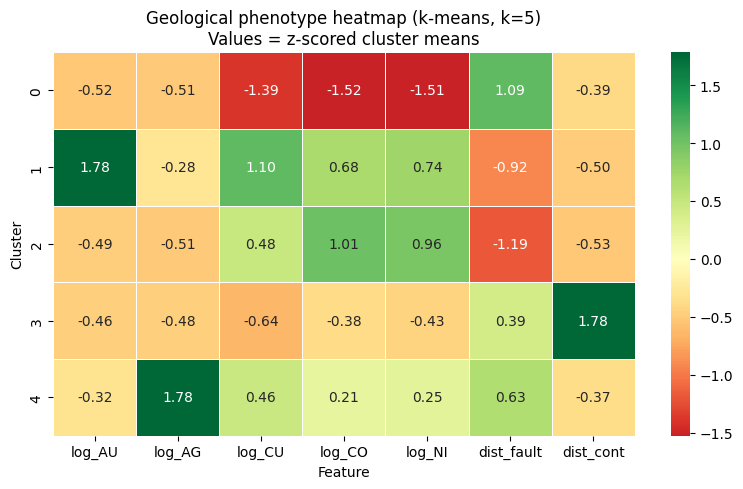

In [17]:
df_interp = df.copy()  # use the cleaned (whitespace-fixed) version
df_interp['kmeans_cluster'] = kmeans_labels
df_interp['gmm_cluster'] = gmm_matched_labels

for m in MINERAL_COLS:
    df_interp[f'log_{m}'] = np.log1p(df_interp[m])

heatmap_features = [f'log_{m}' for m in MINERAL_COLS] + DISTANCE_COLS
heatmap_features = [f for f in heatmap_features if f in df_interp.columns]

cluster_means = df_interp.groupby('kmeans_cluster')[heatmap_features].mean()
cluster_means_z = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-9)

fig, ax = plt.subplots(figsize=(max(8, len(heatmap_features)), K_BEST))
sns.heatmap(cluster_means_z, annot=True, fmt='.2f', cmap='RdYlGn', center=0, linewidths=0.5, ax=ax)
ax.set_title(f'Geological phenotype heatmap (k-means, k={K_BEST})\nValues = z-scored cluster means')
ax.set_xlabel('Feature'); ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/phenotype_heatmap.png', dpi=150)
plt.show()

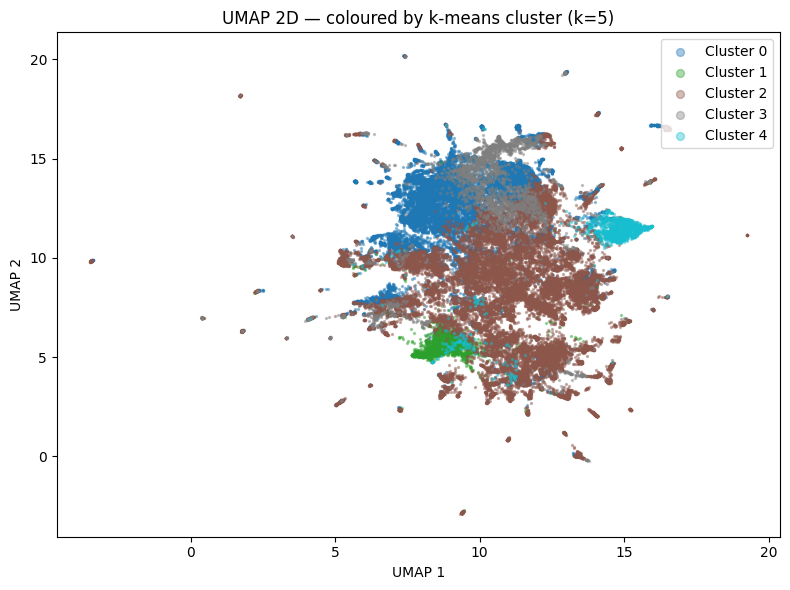

In [18]:
palette = plt.cm.get_cmap('tab10', K_BEST)

fig, ax = plt.subplots(figsize=(8, 6))
for k in range(K_BEST):
    mask = kmeans_labels == k
    ax.scatter(X_umap2[mask, 0], X_umap2[mask, 1], s=2, alpha=0.4, color=palette(k), label=f'Cluster {k}')
ax.set_title(f'UMAP 2D — coloured by k-means cluster (k={K_BEST})')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.legend(markerscale=4, loc='upper right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/umap_scatter.png', dpi=150)
plt.show()

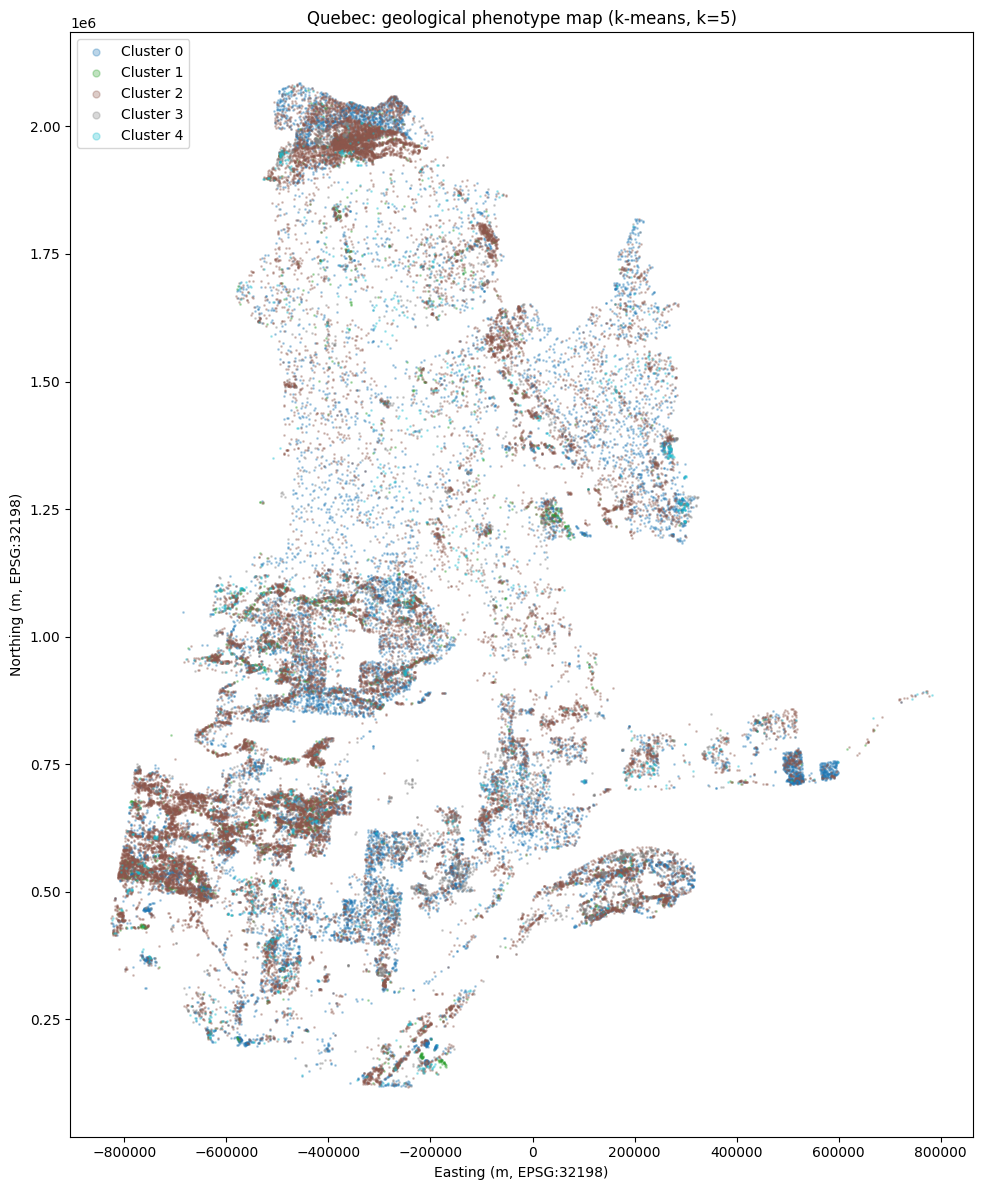

In [19]:
fig, ax = plt.subplots(figsize=(10, 12))
for k in range(K_BEST):
    mask = df_interp['kmeans_cluster'] == k
    ax.scatter(df_interp.loc[mask, 'Easting'], df_interp.loc[mask, 'Northing'],
               s=1, alpha=0.3, color=palette(k), label=f'Cluster {k}')
ax.set_title(f'Quebec: geological phenotype map (k-means, k={K_BEST})')
ax.set_xlabel('Easting (m, EPSG:32198)'); ax.set_ylabel('Northing (m, EPSG:32198)')
ax.legend(markerscale=5, loc='upper left')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/quebec_phenotype_map.png', dpi=150)
plt.show()

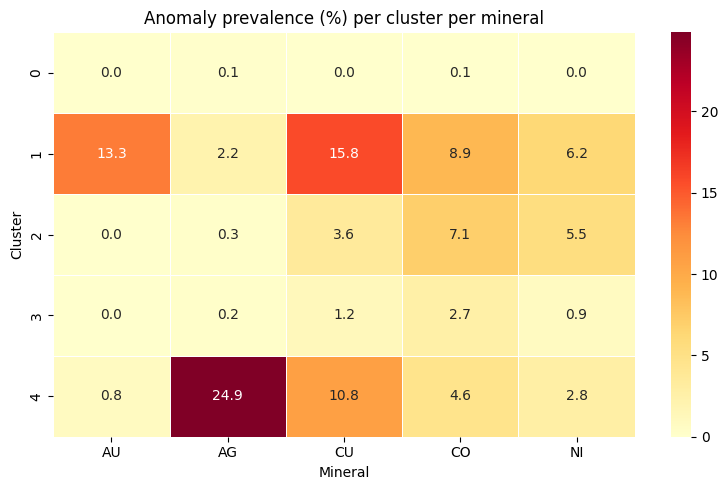

In [20]:
# Anomaly prevalence per cluster per mineral — links phenotypes to the supervised task
target_cols_present = [c for c in TARGET_COLS if c in df_interp.columns]
prev = df_interp.groupby('kmeans_cluster')[target_cols_present].mean() * 100
prev.columns = [c.replace('target_', '') for c in target_cols_present]

fig, ax = plt.subplots(figsize=(8, K_BEST))
sns.heatmap(prev, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Anomaly prevalence (%) per cluster per mineral')
ax.set_xlabel('Mineral'); ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/anomaly_prevalence.png', dpi=150)
plt.show()

In [21]:
# Top lithology codes (multi-hot) per cluster — geological face validity
for k in range(K_BEST):
    mask = df_interp['kmeans_cluster'] == k
    top_lith = df_interp.loc[mask, lith_ohe_cols].sum().sort_values(ascending=False).head(5)
    top_lith_pct = (top_lith / mask.sum() * 100)
    print(f'\nCluster {k} (n={mask.sum():,}) — top lithology codes:')
    for lith, pct in top_lith_pct.items():
        print(f'  {lith:<10} present in {pct:.1f}% of cluster members')


Cluster 0 (n=14,513) — top lithology codes:
  I1D        present in 20.3% of cluster members
  I1B        present in 16.7% of cluster members
  I1C        present in 13.5% of cluster members
  M4         present in 10.4% of cluster members
  M1         present in 5.9% of cluster members

Cluster 1 (n=1,950) — top lithology codes:
  V3B        present in 32.9% of cluster members
  M16        present in 17.0% of cluster members
  I3A        present in 15.1% of cluster members
  M4         present in 13.2% of cluster members
  I1D        present in 11.2% of cluster members

Cluster 2 (n=27,215) — top lithology codes:
  V3B        present in 24.2% of cluster members
  I3A        present in 16.1% of cluster members
  M16        present in 14.1% of cluster members
  M4         present in 10.7% of cluster members
  I1D        present in 8.0% of cluster members

Cluster 3 (n=2,956) — top lithology codes:
  I1D        present in 18.7% of cluster members
  I1B        present in 12.6% of cluster

## 9. Nested model test (central contribution)

Compare three XGBoost variants per mineral using a **spatial holdout**:
- **Model A** — raw tabular features only
- **Model B** — phenotype cluster label only
- **Model C** — raw features + phenotype label

Report AUROC and PR-AUC with 1000-bootstrap 95% CIs. If AUROC(C) − AUROC(A)'s CI excludes zero, phenotype membership adds significant value.

**Coordinate the spatial split below with your teammate** so this is comparable to his supervised XGBoost holdout.

In [22]:

df_model = df_interp.copy()

# Geology-only predictors.
# Intentionally exclude ALL log_* mineral concentration columns to prevent
# target leakage and soft leakage between correlated mineral assays.
base_feature_cols = (
    DISTANCE_COLS
    + lith_ohe_cols
    + [c for c in df_model.columns if c.startswith('STRAT_')]
)

# STRAT_ columns don't exist on df_model yet — pull from strat_ohe and merge
df_model = pd.concat([df_model, strat_ohe], axis=1)

base_feature_cols = [c for c in base_feature_cols if c in df_model.columns]

print(f'Model dataset: {df_model.shape}')
print(f'Geology-only features: {len(base_feature_cols)}')


Model dataset: (48166, 954)
Geology-only features: 223


In [23]:
SPATIAL_SPLIT_COL = 'Northing'
SPATIAL_SPLIT_PCT = 0.80  # top 20% of northings = test (geographically contiguous)

split_threshold = df_model[SPATIAL_SPLIT_COL].quantile(SPATIAL_SPLIT_PCT)
train_mask_all = df_model[SPATIAL_SPLIT_COL] <= split_threshold
print(f'Train: {train_mask_all.sum():,}  |  Test: {(~train_mask_all).sum():,}')
print(f'Split on {SPATIAL_SPLIT_COL} <= {split_threshold:.0f}m')

Train: 38,533  |  Test: 9,633
Split on Northing <= 1517190m


In [24]:
from sklearn.model_selection import train_test_split

def bootstrap_ci(y_true, y_score, metric_fn, n_bootstrap=1000, ci=0.95, seed=SEED):
    rng = np.random.default_rng(seed)
    scores = []
    n = len(y_true)
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)
        try:
            scores.append(metric_fn(y_true[idx], y_score[idx]))
        except ValueError:
            pass
    alpha = (1 - ci) / 2
    return (
        float(metric_fn(y_true, y_score)),
        float(np.quantile(scores, alpha)),
        float(np.quantile(scores, 1 - alpha))
    )


def run_xgb(X_train, y_train, X_test, y_test, label=''):
    scale_pos = max(1, (y_train == 0).sum() / max(1, (y_train == 1).sum()))
    model = xgb.XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos, eval_metric='aucpr',
        random_state=SEED, n_jobs=-1
    )
    X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2,stratify=y_train,random_state=SEED)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],verbose=False)
    proba = model.predict_proba(X_test)[:, 1]
    auroc = bootstrap_ci(y_test, proba, roc_auc_score)
    prauc = bootstrap_ci(y_test, proba, average_precision_score)
    return {'label': label, 'auroc': auroc, 'prauc': prauc, 'model': model}

print('Helper functions defined.')

Helper functions defined.


In [25]:
results = {}

for mineral in MINERAL_COLS:
    target_col = f'target_{mineral}'
    if target_col not in df_model.columns:
        print(f'Skipping {mineral} — target column not found.')
        continue

    valid = df_model[target_col].notna()
    df_m = df_model[valid].copy()

    y = df_m[target_col].astype(int).values
    train_m = (df_m[SPATIAL_SPLIT_COL] <= split_threshold).values
    test_m = ~train_m

    if y[test_m].sum() < 10:
        print(f'Skipping {mineral} — fewer than 10 positives in test set.')
        continue

    print(f'\n-- {mineral} --------------------------------------')
    print(f'   Train positives: {y[train_m].sum()}  |  Test positives: {y[test_m].sum()}')

    
    train_df = df_m.loc[train_m, base_feature_cols]
    medians = train_df.median()

    X_train_raw_df = df_m.loc[train_m, base_feature_cols].fillna(medians)
    X_test_raw_df  = df_m.loc[test_m, base_feature_cols].fillna(medians)

    X_A_train = X_train_raw_df.values
    X_A_test  = X_test_raw_df.values
    
    
    cluster_train = pd.get_dummies(
        df_m.loc[train_m, 'kmeans_cluster'],
        prefix='phenotype'
    )
    cluster_test = pd.get_dummies(
        df_m.loc[test_m, 'kmeans_cluster'],
        prefix='phenotype'
    )

    cluster_train, cluster_test = cluster_train.align(
        cluster_test,
        join='outer',
        axis=1,
        fill_value=0
    )

    X_B_train = cluster_train.values
    X_B_test = cluster_test.values

    X_C_train = np.hstack([X_A_train, X_B_train])
    X_C_test = np.hstack([X_A_test, X_B_test])

    y_train, y_test = y[train_m], y[test_m]

    res_A = run_xgb(X_A_train, y_train, X_A_test, y_test, label='A: geology only')
    res_B = run_xgb(X_B_train, y_train, X_B_test, y_test, label='B: phenotype only')
    res_C = run_xgb(X_C_train, y_train, X_C_test, y_test, label='C: geology + phenotype')
    

    results[mineral] = {'A': res_A, 'B': res_B, 'C': res_C}

    for res in [res_A, res_B, res_C]:
        a, p = res['auroc'], res['prauc']
        print(f"  {res['label']:<25}  AUROC {a[0]:.4f} [{a[1]:.4f}, {a[2]:.4f}]  PR-AUC {p[0]:.4f} [{p[1]:.4f}, {p[2]:.4f}]")


-- AU --------------------------------------
   Train positives: 173  |  Test positives: 10
  A: geology only            AUROC 0.5763 [0.3446, 0.7781]  PR-AUC 0.0047 [0.0016, 0.0122]
  B: phenotype only          AUROC 0.9634 [0.9594, 0.9673]  PR-AUC 0.0295 [0.0127, 0.0473]
  C: geology + phenotype     AUROC 0.9660 [0.9511, 0.9790]  PR-AUC 0.0371 [0.0156, 0.0863]

-- AG --------------------------------------
   Train positives: 289  |  Test positives: 61
  A: geology only            AUROC 0.5506 [0.4789, 0.6134]  PR-AUC 0.0217 [0.0161, 0.0311]
  B: phenotype only          AUROC 0.9603 [0.9555, 0.9650]  PR-AUC 0.1949 [0.1528, 0.2386]
  C: geology + phenotype     AUROC 0.9602 [0.9516, 0.9682]  PR-AUC 0.1980 [0.1504, 0.2705]

-- CU --------------------------------------
   Train positives: 634  |  Test positives: 339
  A: geology only            AUROC 0.5623 [0.5298, 0.5974]  PR-AUC 0.0447 [0.0383, 0.0533]
  B: phenotype only          AUROC 0.7257 [0.7075, 0.7444]  PR-AUC 0.0808 [0.0678, 

In [26]:
rows = []
for mineral, res in results.items():
    for key, label in [('A', 'raw only'), ('B', 'phenotype only'), ('C', 'raw + phenotype')]:
        auroc, prauc = res[key]['auroc'], res[key]['prauc']
        rows.append({
            'Mineral': mineral, 'Model': label,
            'AUROC': round(auroc[0], 4), 'AUROC_lo': round(auroc[1], 4), 'AUROC_hi': round(auroc[2], 4),
            'PR_AUC': round(prauc[0], 4), 'PR_AUC_lo': round(prauc[1], 4), 'PR_AUC_hi': round(prauc[2], 4),
        })

df_results = pd.DataFrame(rows)
print('\nFull results table:')
display(df_results)

results_path = f'{OUTPUT_DIR}/unsupervised_nested_model_results.csv'
df_results.to_csv(results_path, index=False)
print(f'Saved to {results_path}')


Full results table:


,Mineral,Model,AUROC,AUROC_lo,AUROC_hi,PR_AUC,PR_AUC_lo,PR_AUC_hi
0,AU,raw only,0.5763,0.3446,0.7781,0.0047,0.0016,0.0122
1,AU,phenotype only,0.9634,0.9594,0.9673,0.0295,0.0127,0.0473
2,AU,raw + phenotype,0.9660,0.9511,0.9790,0.0371,0.0156,0.0863
3,AG,raw only,0.5506,0.4789,0.6134,0.0217,0.0161,0.0311
4,AG,phenotype only,0.9603,0.9555,0.9650,0.1949,0.1528,0.2386
5,AG,raw + phenotype,0.9602,0.9516,0.9682,0.1980,0.1504,0.2705
6,CU,raw only,0.5623,0.5298,0.5974,0.0447,0.0383,0.0533
7,CU,phenotype only,0.7257,0.7075,0.7444,0.0808,0.0678,0.0970
8,CU,raw + phenotype,0.7498,0.7263,0.7724,0.1117,0.0923,0.1419
9,CO,raw only,0.6180,0.5894,0.6472,0.1555,0.1292,0.1908


Saved to ./outputs_v4/unsupervised_nested_model_results.csv


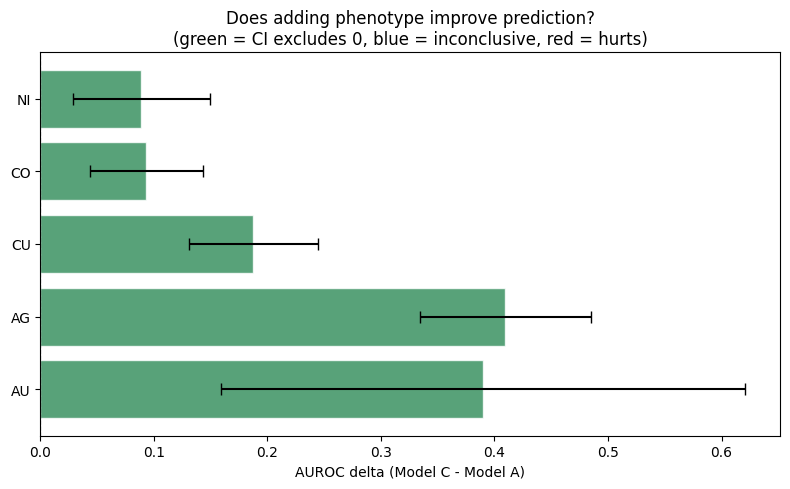

In [27]:
fig, ax = plt.subplots(figsize=(8, max(3, len(results))))
minerals_list = list(results.keys())
y_pos = np.arange(len(minerals_list))

for i, mineral in enumerate(minerals_list):
    auroc_A = results[mineral]['A']['auroc']
    auroc_C = results[mineral]['C']['auroc']
    delta = auroc_C[0] - auroc_A[0]
    half_A = (auroc_A[2] - auroc_A[1]) / 2
    half_C = (auroc_C[2] - auroc_C[1]) / 2
    delta_err = half_A + half_C

    color = 'seagreen' if (delta - delta_err) > 0 else ('coral' if (delta + delta_err) < 0 else 'steelblue')
    ax.barh(i, delta, xerr=delta_err, color=color, alpha=0.8, capsize=4, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_yticks(y_pos); ax.set_yticklabels(minerals_list)
ax.set_xlabel('AUROC delta (Model C - Model A)')
ax.set_title('Does adding phenotype improve prediction?\n(green = CI excludes 0, blue = inconclusive, red = hurts)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/auroc_delta.png', dpi=150)
plt.show()

## 9B. Cluster Interpretation Summary

Summarize the geological meaning of each K-Means cluster by reporting cluster size and dominant lithology codes. This supports cluster face-validity and interpretability.


In [28]:

cluster_summary = []

for c in sorted(np.unique(kmeans_labels)):
    mask = kmeans_labels == c
    size = int(mask.sum())

    lith_counts = df.loc[mask, 'CODE_LITH'].value_counts()
    top_lith = ', '.join(lith_counts.head(3).index.tolist())

    cluster_summary.append({
        'Cluster': c,
        'Size': size,
        'Percent': round(100 * size / len(kmeans_labels), 2),
        'Top Lithologies': top_lith
    })

cluster_summary_df = pd.DataFrame(cluster_summary)
display(cluster_summary_df)

cluster_summary_df.to_csv(
    f'{OUTPUT_DIR}/cluster_interpretation_summary.csv',
    index=False
)


,Cluster,Size,Percent,Top Lithologies
0,0,14513,30.13,"I1D, I1B, I1C"
1,1,1950,4.05,"V3B, M4-M22, I1D"
2,2,27215,56.50,"V3B, I3A, I1D"
3,3,2956,6.14,"I3G, I1D, I1B"
4,4,1532,3.18,"I1D, V3B, I1B"


## 9C. Explicit Sensitivity Analysis

Evaluate robustness of the selected K=5 solution by comparing neighboring values of K. This complements the model-selection plots and demonstrates sensitivity to hyperparameter choices.


,K,Silhouette,Davies_Bouldin,Cluster_Count
0,4,0.188243,1.759854,4
1,5,0.193855,1.549764,5
2,6,0.189665,1.500880,6


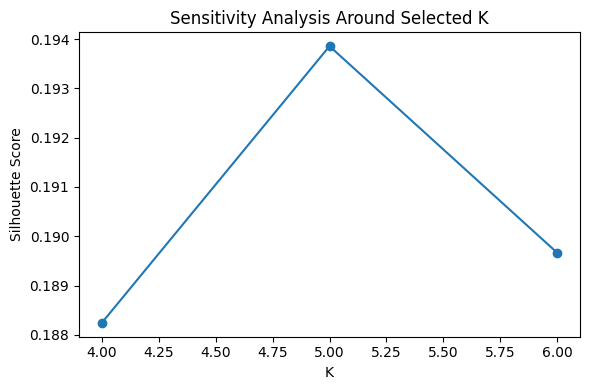

In [29]:
sensitivity_rows = []

for k in [max(2, K_BEST-1), K_BEST, K_BEST+1]:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=20,
        random_state=SEED
    )
    labels = km.fit_predict(X_pca)

    # FIX: draw ONE shared index for both X_pca and labels, instead of two
    # independent random samples. The original version sampled X_pca and
    # labels separately, so the silhouette score was being computed on
    # mismatched rows -- that's why it came back negative here despite
    # being ~0.19 (positive) for the same k values in section 5.
    if len(X_pca) > 10000:
        idx = np.random.choice(len(X_pca), 10000, replace=False)
        sil = silhouette_score(X_pca[idx], labels[idx])
    else:
        sil = silhouette_score(X_pca, labels)

    db = davies_bouldin_score(X_pca, labels)
    sensitivity_rows.append({
        'K': k,
        'Silhouette': sil,
        'Davies_Bouldin': db,
        'Cluster_Count': len(np.unique(labels))
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

plt.figure(figsize=(6,4))
plt.plot(sensitivity_df['K'], sensitivity_df['Silhouette'], marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Sensitivity Analysis Around Selected K')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sensitivity_kmeans.png', dpi=150)
plt.show()

## 10. Save cluster labels

Save the cluster labels for the fusion model if needed.

In [30]:
df_labels = df[['Sample_ID', 'Easting', 'Northing']].copy()
df_labels['kmeans_cluster'] = kmeans_labels
df_labels['gmm_cluster'] = gmm_matched_labels

for i in range(K_BEST):
    df_labels[f'gmm_prob_{i}'] = gmm_matched_proba[:, i]

labels_path = f'{OUTPUT_DIR}/cluster_labels.csv'
df_labels.to_csv(labels_path, index=False)
print(f'Cluster labels saved: {df_labels.shape}')
print(f'Path: {labels_path}')
df_labels.head()

Cluster labels saved: (48166, 10)
Path: ./outputs_v4/cluster_labels.csv


,Sample_ID,Easting,Northing,kmeans_cluster,gmm_cluster,gmm_prob_0,gmm_prob_1,gmm_prob_2,gmm_prob_3,gmm_prob_4
0,1.0,-826018.885019,439508.645145,2,0,1.000000e+00,9.262119e-28,7.176149e-53,1.816285e-17,2.093438e-70
1,2.0,-825408.935432,448162.338995,2,4,2.405813e-12,2.288202e-23,1.369793e-10,6.330707e-07,9.999994e-01
2,4.0,-824710.538210,452893.924796,2,1,0.000000e+00,1.000000e+00,4.554066e-48,4.904081e-41,1.478130e-116
3,6.5,-824130.040813,438882.369942,0,3,1.275609e-43,1.332513e-22,2.269080e-15,1.000000e+00,2.512481e-16
4,8.0,-823281.410385,445223.349511,4,2,0.000000e+00,2.135995e-138,1.000000e+00,2.195046e-111,2.067536e-156
